## **Libraries**

In [1]:
pip install kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

## **Dataset**

In [3]:
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")
print("Path to dataset files:", path)

file_path = os.path.join(path, 'loan_approval_dataset.csv')
print(f"Joined file path: {file_path}")

Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/loan-approval-prediction-dataset
Joined file path: /kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv


## **Exploratory Data Analysis**

In [5]:
df = pd.read_csv(file_path)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.columns = df.columns.str.strip()

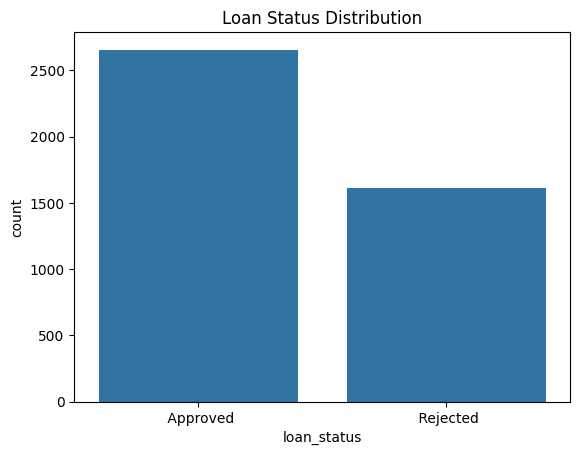

,proportion
loan_status,
Approved,0.62216
Rejected,0.37784


In [ ]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

df['loan_status'].value_counts()
df['loan_status'].value_counts(normalize=True)

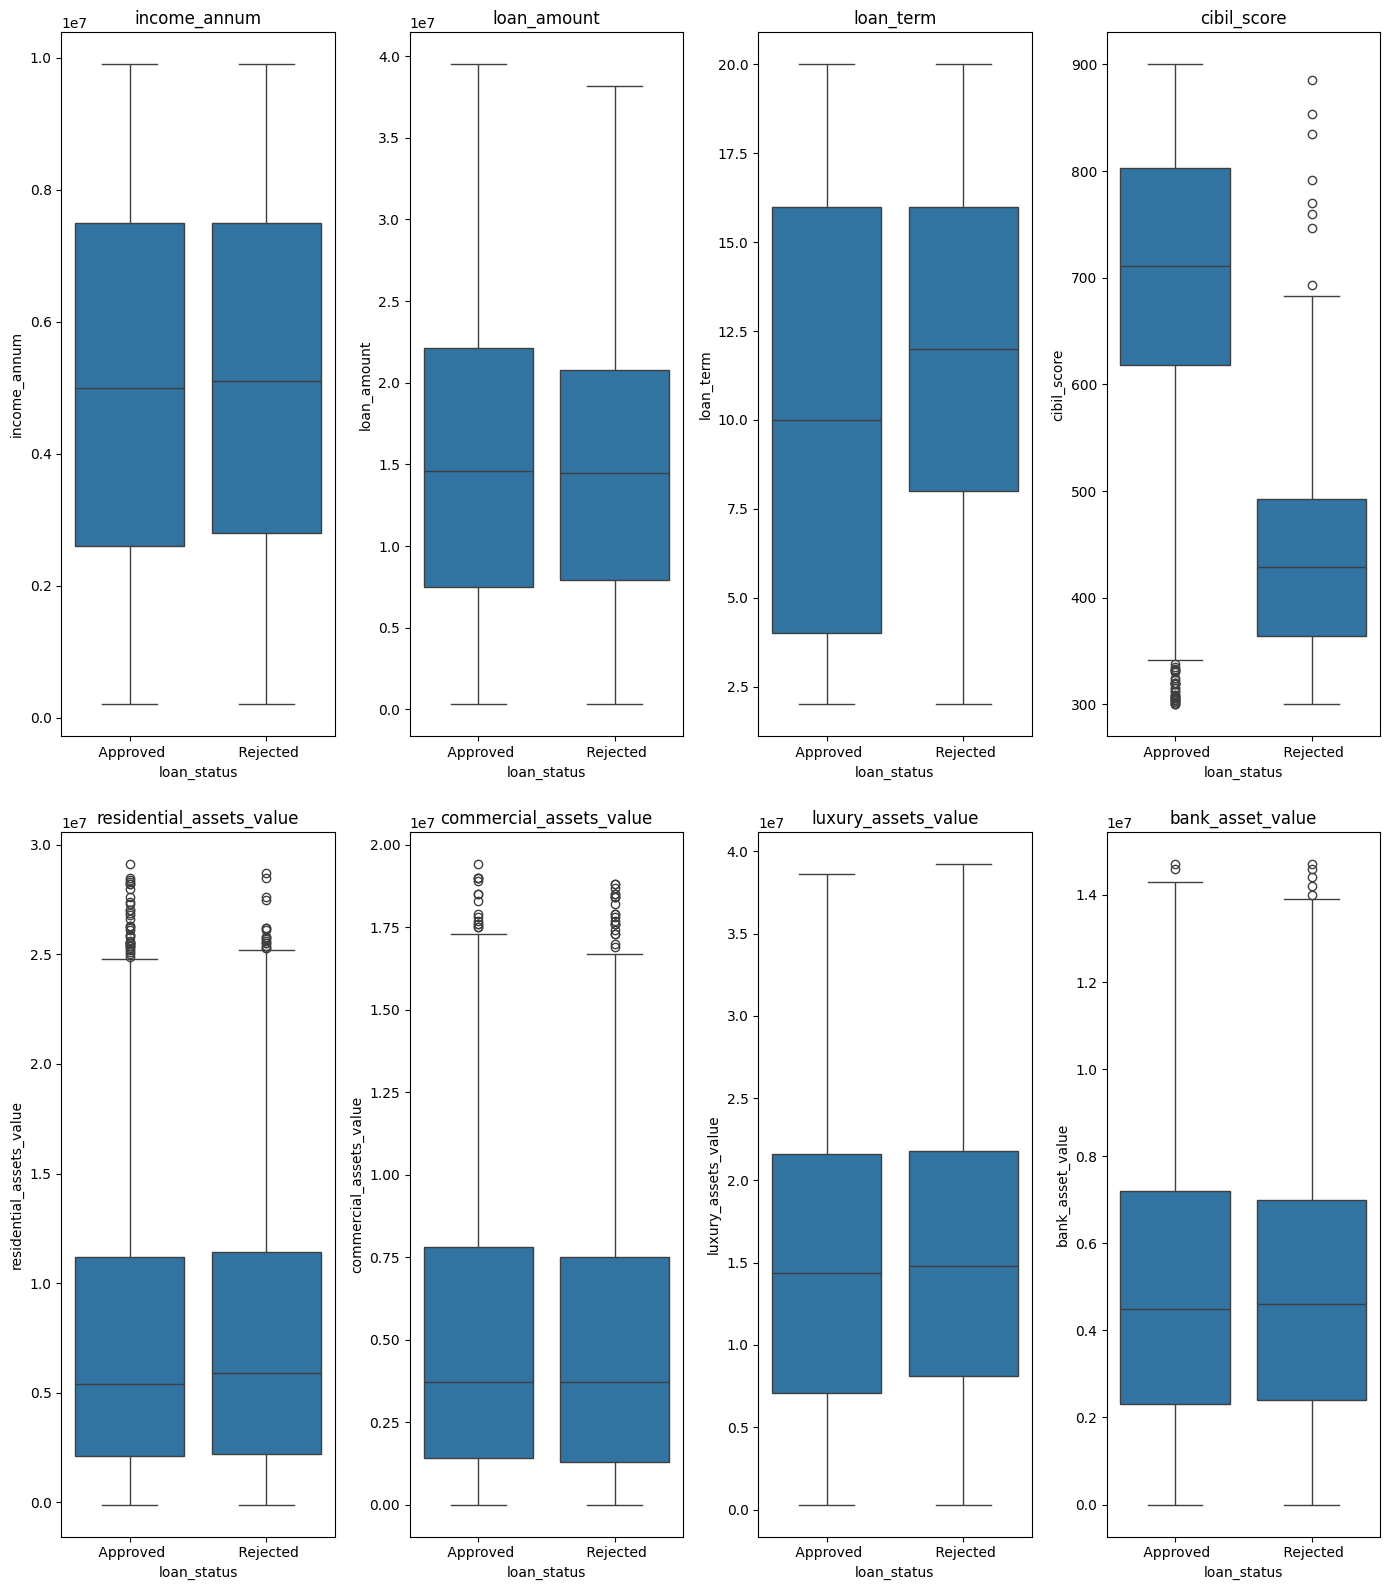

In [ ]:
numerical_cols = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

plt.figure(figsize=(14,16))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
numerical_cols = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

outliers_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    num_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    outliers_summary.append([col, num_outliers])

outliers_summary_df = pd.DataFrame(outliers_summary, columns=['Feature', 'Number of Outliers'])
outliers_summary_df


,Feature,Number of Outliers
0,income_annum,0
1,loan_amount,0
2,loan_term,0
3,cibil_score,0
4,residential_assets_value,52
5,commercial_assets_value,37
6,luxury_assets_value,0
7,bank_asset_value,5


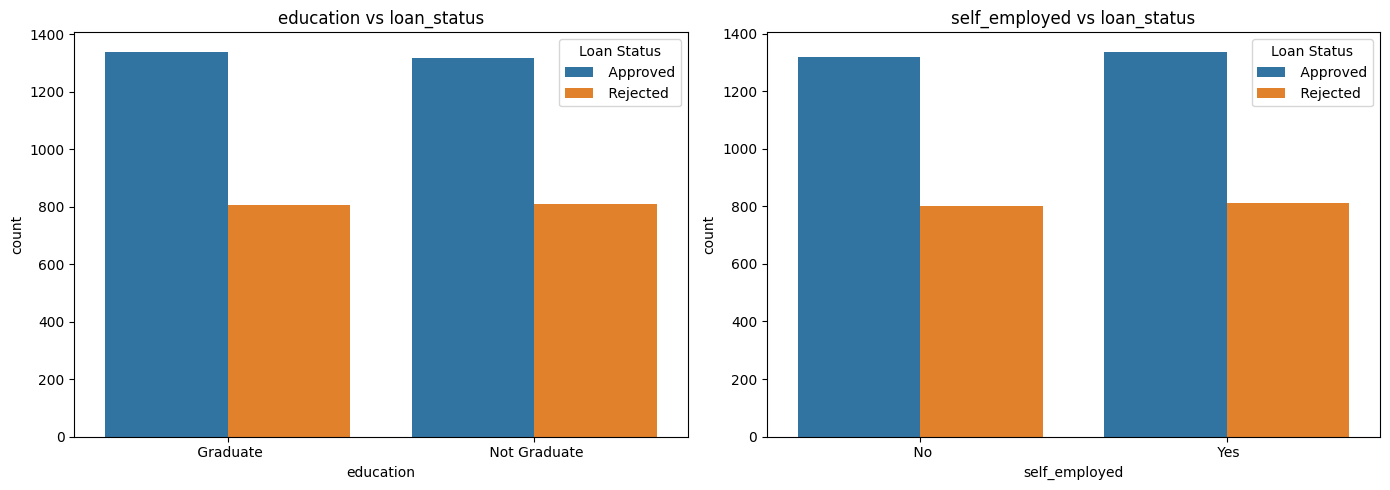

In [ ]:
categorical_cols = ['education', 'self_employed']
target = 'loan_status'

plt.figure(figsize=(14,5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=col, hue=target, data=df)
    plt.title(f"{col} vs {target}")
    plt.legend(title='Loan Status')

plt.tight_layout()
plt.show()


The dataset contains 4,269 records, with 62% approved and 38% rejected loans, indicating a moderate class imbalance. This suggests that evaluation should focus on precision, recall, and F1-score, rather than just accuracy.

Among the numerical features, cibil_score shows clear separation between approved and rejected loans, making it a strong predictor. Some asset-related features (residential_assets_value, commercial_assets_value, bank_asset_value) have extreme values or outliers, which may need attention before modeling. Other numerical features are clean and well-behaved.

The categorical features, education and self_employed, show almost identical approval rates across their categories, indicating minimal predictive power.

In summary, numerical features especially credit score and assets are the most informative for predicting loan approval, while categorical features are weak predictors. The dataset is clean, with moderate class imbalance, and ready for preprocessing and modeling.

## **Preprocessing Data**

In [ ]:
df_encoded = df.copy()
df_encoded = df_encoded.drop('loan_id', axis=1)

In [ ]:
df_encoded['education'] = df_encoded['education'].str.strip().map({'Graduate':0, 'Not Graduate':1})
df_encoded['self_employed'] = df_encoded['self_employed'].str.strip().map({'No':0, 'Yes':1})
df_encoded['loan_status'] = df_encoded['loan_status'].str.strip().map({'Approved':1, 'Rejected':0})

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


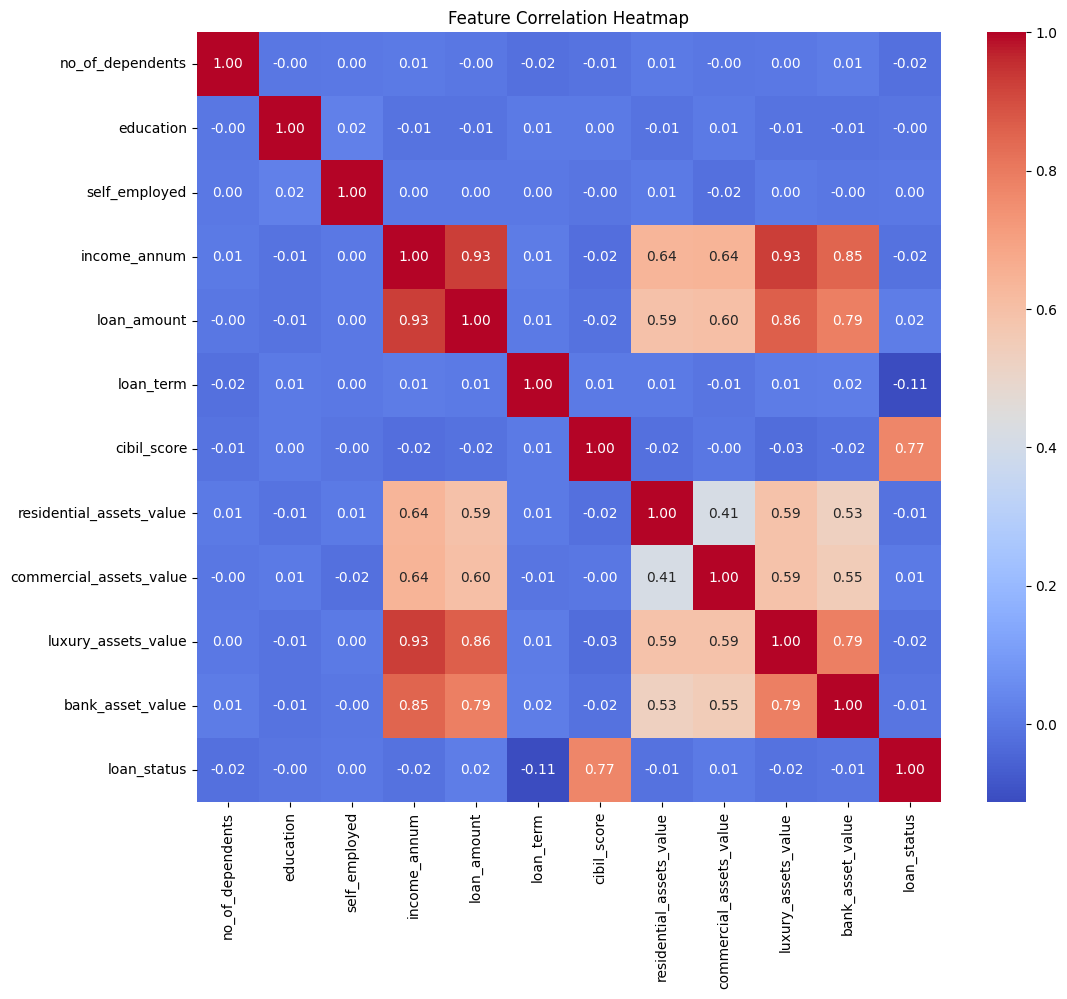

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Training set stats after capping:
       residential_assets_value  commercial_assets_value  bank_asset_value
count              3.415000e+03             3.415000e+03      3.415000e+03
mean               7.397189e+06             4.955903e+06      4.978568e+06
std                6.380853e+06             4.335320e+06      3.217293e+06
min                0.000000e+00             0.000000e+00      2.000000e+05
25%                2.200000e+06             1.300000e+06      2.400000e+06
50%                5.600000e+06             3.700000e+06      4.500000e+06
75%                1.120000e+07             7.600000e+06      7.000000e+06
max                2.530000e+07             1.688600e+07      1.318600e+07

Test set stats after capping:
       residential_assets_value  commercial_assets_value  bank_asset_value
count              8.540000e+02             8.540000e+02      8.540000e+02
mean               7.709016e+06             4.990400e+06      4.946857e+06
std                6.778583e+06    

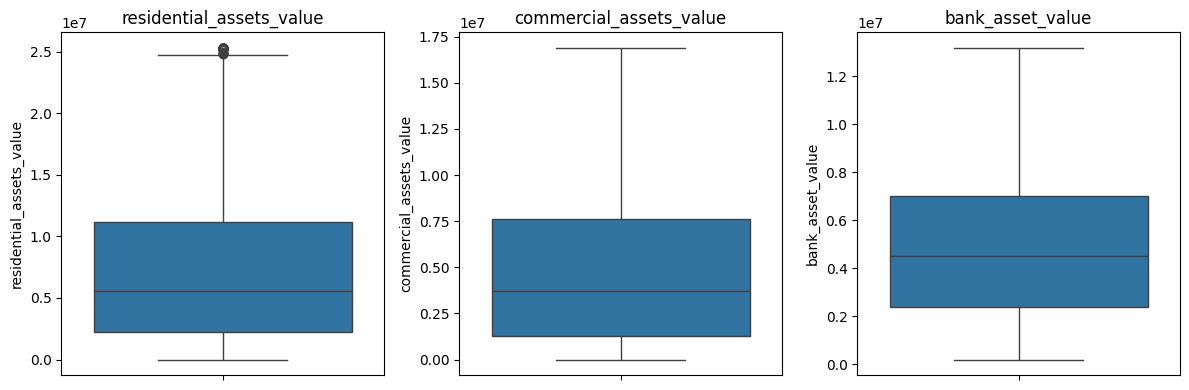

In [ ]:
outlier_cols = ['residential_assets_value', 'commercial_assets_value', 'bank_asset_value']

for col in outlier_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

print("Training set stats after capping:")
print(X_train[outlier_cols].describe())

print("\nTest set stats after capping:")
print(X_test[outlier_cols].describe())

plt.figure(figsize=(12,4))
for i, col in enumerate(outlier_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=X_train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

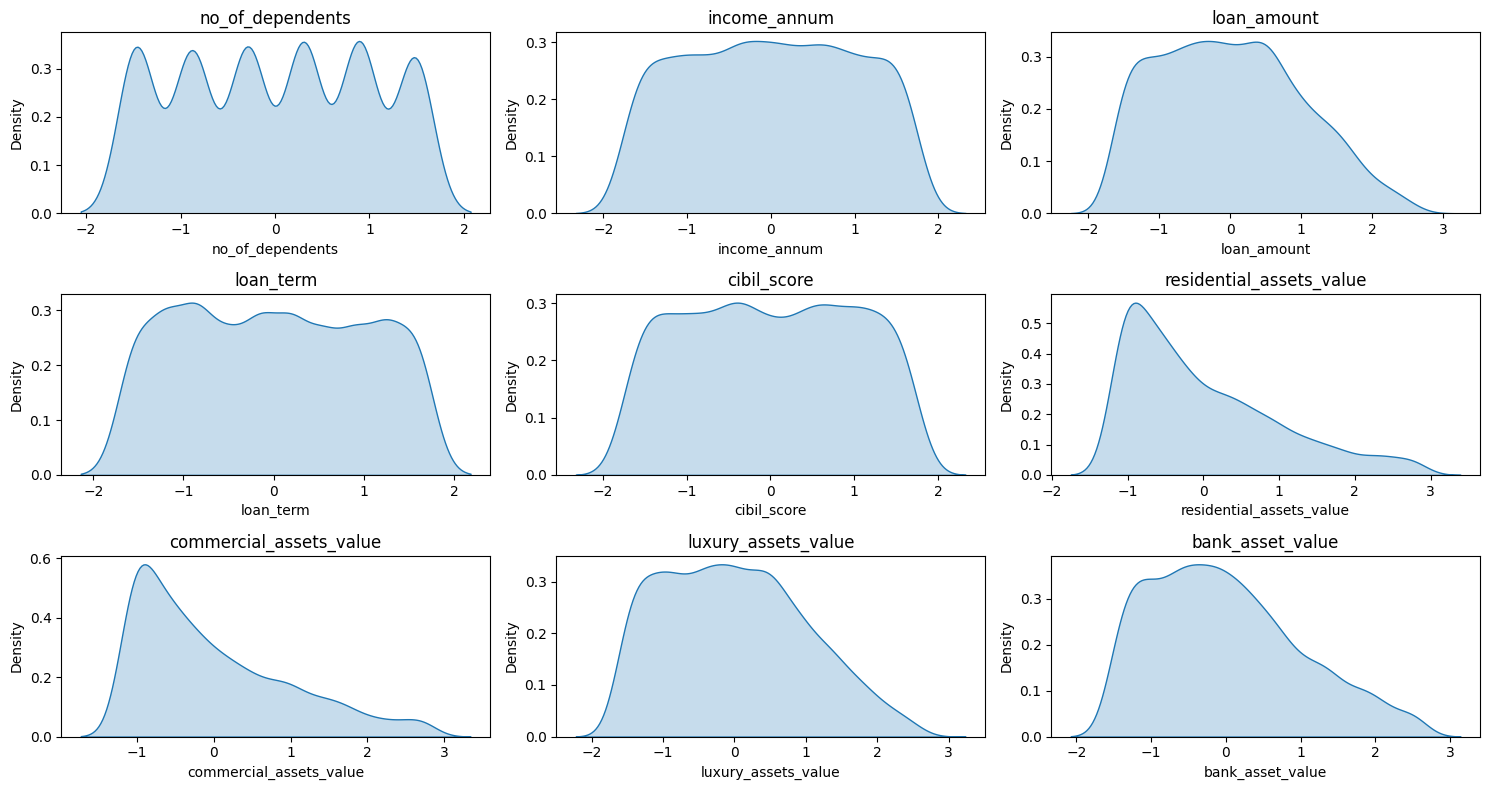

In [ ]:
num_cols = ['no_of_dependents','income_annum','loan_amount','loan_term',
            'cibil_score','residential_assets_value','commercial_assets_value',
            'luxury_assets_value','bank_asset_value']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(X_train[col], fill=True)
    plt.title(col)
plt.tight_layout()
plt.show()

We started by encoding categorical features (education and self_employed) and the target (loan_status) into 0/1 integers. Extra spaces were removed to prevent errors, ensuring all values were correctly mapped.

Next, we split the dataset into training and testing sets to prevent data leakage. After splitting, we addressed outliers in three numerical features (residential_assets_value, commercial_assets_value, bank_asset_value) by capping extreme values at the 1st and 99th percentiles. This reduced the influence of extreme values on the logistic regression model.

Finally, we scaled all numerical features using StandardScaler, fitting it on the training set and applying the same transformation to the test set. Distributions were visualized to confirm that features were standardized, making them ready for model training.

## **Logistic Regression Model**

In [ ]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

Training Accuracy: 0.9180
Testing Accuracy: 0.9122


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Confusion Matrix:
[[279  44]
 [ 31 500]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



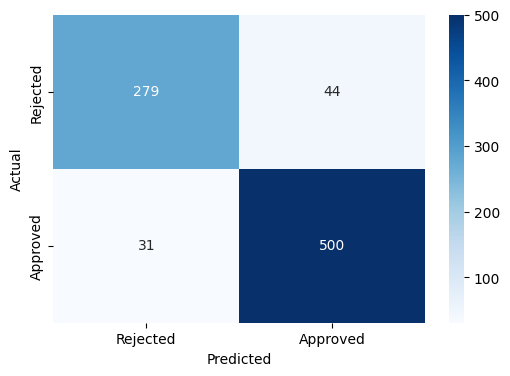

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model is correctly predicting most loan approvals and rejections. Out of 323 actual rejections, 279 were correctly predicted (true negatives), and 44 were misclassified (false positives). For 531 actual approvals, 500 were correctly predicted (true positives), with 31 misclassified (false negatives).

The classification report indicates strong performance: precision, recall, and F1-score are all above 0.88 for both classes. Accuracy on the test set is 91%, showing that the model generalizes well. Recall for approvals (class 1) is particularly high at 0.94, meaning the model correctly identifies most approved loans, which is often important for business decisions.

Overall, logistic regression performs solidly on this dataset, with slightly better performance in predicting approvals than rejections.

## **SMOTE**

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
logreg_smote = LogisticRegression(random_state=42, max_iter=1000)
logreg_smote.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_test_pred_smote = logreg_smote.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred_smote)
print(f"Testing Accuracy: {test_acc:.4f}")

Testing Accuracy: 0.9215


In [ ]:
cm = confusion_matrix(y_test, y_test_pred_smote)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_smote))


Confusion Matrix:
[[297  26]
 [ 41 490]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       323
           1       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.91      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854



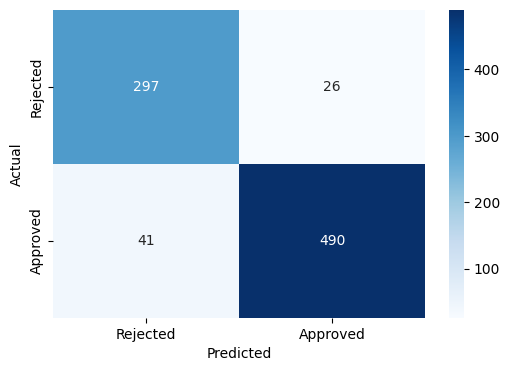

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Before applying SMOTE, the logistic regression model performed well overall, with high precision and F1-scores. However, the recall for the minority class (Rejected loans) was slightly lower at 0.86, indicating that some rejected applications were being misclassified as approved. The model was slightly biased toward predicting approvals, which is common with imbalanced datasets.

After applying SMOTE, the model’s performance for the minority class improved. Recall for rejected loans increased to 0.92, meaning the model now correctly identifies more of the rejected applications. Precision for rejections slightly decreased to 0.88, but the overall F1-score improved to 0.90. The approved class remained strong, with high precision and F1-score, showing that SMOTE helped balance the model’s performance across both classes.

Overall, SMOTE made the model more robust for imbalanced data by improving minority class detection without significantly hurting performance on the majority class.
| Model                          | Loan Status | Precision | Recall | F1-score |
| ------------------------------ | ----------- | --------- | ------ | -------- |
| Logistic Regression (Original) | Rejected    | 0.90      | 0.86   | 0.88     |
|                                | Approved    | 0.92      | 0.94   | 0.93     |
| Logistic Regression (SMOTE)    | Rejected    | 0.88      | 0.92   | 0.90     |
|                                | Approved    | 0.95      | 0.92   | 0.94     |


## **Decission Tree**

In [ ]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_test_pred_tree = dtree.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred_tree)
print(f"Testing Accuracy: {test_acc:.4f}")

Testing Accuracy: 0.9836


In [ ]:
cm = confusion_matrix(y_test, y_test_pred_tree)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_tree))


Confusion Matrix:
[[315   8]
 [  6 525]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



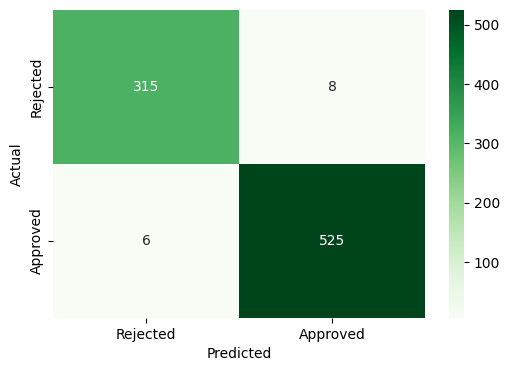

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The decision tree performs extremely well on this dataset. The confusion matrix shows very few misclassifications: only 8 false positives and 6 false negatives.

The classification report confirms this, with both classes showing precision and recall around 0.98–0.99. The F1-scores are similarly high, and overall accuracy is 98%, significantly higher than logistic regression.

Decision trees are naturally robust to feature scaling, outliers, and class imbalance, which explains why it performed so strongly even without SMOTE. Overall, this model is highly accurate for predicting both approved and rejected loans.

## **logistic Regression vs Decision Tree**

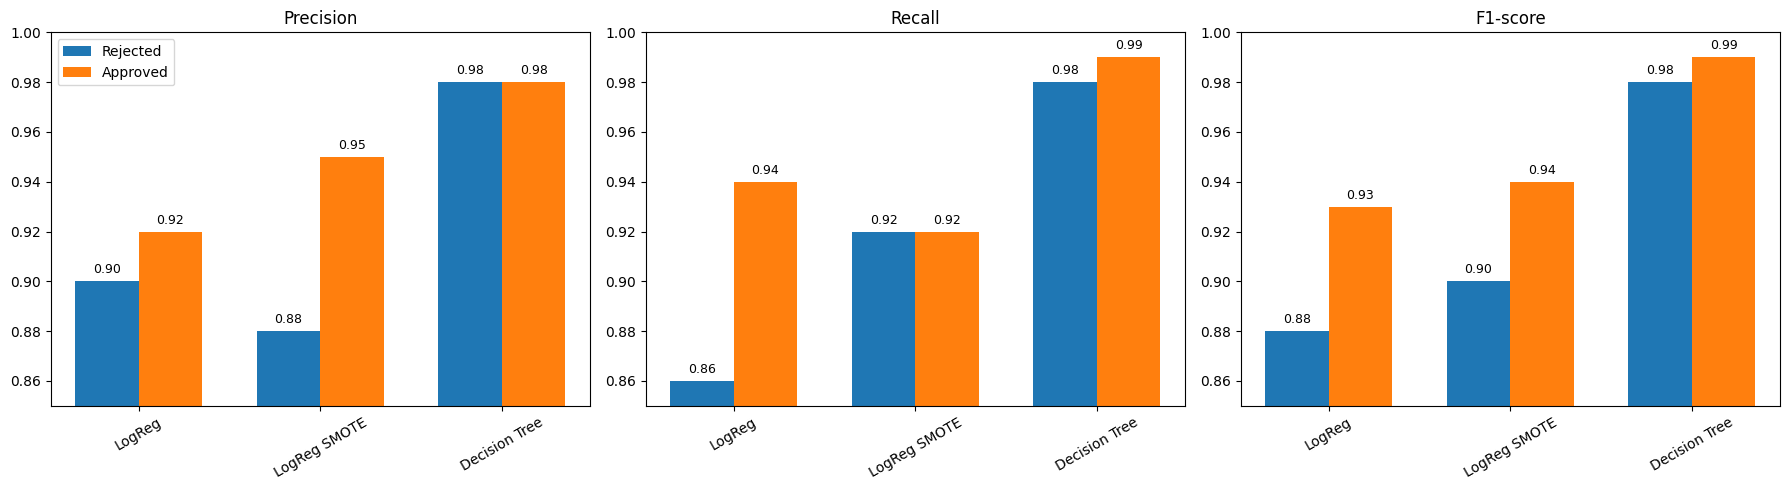

In [ ]:
data = {
    'Model': [
        'LogReg', 'LogReg',
        'LogReg SMOTE', 'LogReg SMOTE',
        'Decision Tree', 'Decision Tree'
    ],
    'Loan Status': [
        'Rejected', 'Approved',
        'Rejected', 'Approved',
        'Rejected', 'Approved'
    ],
    'Precision': [0.90, 0.92, 0.88, 0.95, 0.98, 0.98],
    'Recall': [0.86, 0.94, 0.92, 0.92, 0.98, 0.99],
    'F1-score': [0.88, 0.93, 0.90, 0.94, 0.98, 0.99]
}

df_metrics = pd.DataFrame(data)
metrics = ['Precision', 'Recall', 'F1-score']

x = np.arange(3)
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    rejected_vals = df_metrics[df_metrics['Loan Status']=='Rejected'][metric].values
    approved_vals = df_metrics[df_metrics['Loan Status']=='Approved'][metric].values

    bars_rej = ax.bar(x - width/2, rejected_vals, width, label='Rejected', color='#1f77b4')
    bars_app = ax.bar(x + width/2, approved_vals, width, label='Approved', color='#ff7f0e')

    ax.set_xticks(x)
    ax.set_xticklabels(['LogReg', 'LogReg SMOTE', 'Decision Tree'], rotation=30)
    ax.set_ylim(0.85, 1)
    ax.set_title(metric)
    if i==0:
        ax.legend()

    # Add value labels
    for bar in bars_rej + bars_app:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.002, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


| Model                          | Loan Status | Precision | Recall | F1-score |
| ------------------------------ | ----------- | --------- | ------ | -------- |
| Logistic Regression (Original) | Rejected    | 0.90      | 0.86   | 0.88     |
|                                | Approved    | 0.92      | 0.94   | 0.93     |
| Logistic Regression (SMOTE)    | Rejected    | 0.88      | 0.92   | 0.90     |
|                                | Approved    | 0.95      | 0.92   | 0.94     |
| Decision Tree                  | Rejected    | 0.98      | 0.98   | 0.98     |
|                                | Approved    | 0.98      | 0.99   | 0.99     |


The charts clearly show the performance differences between the three models. Decision tree consistently outperforms logistic regression in all metrics, achieving near-perfect precision, recall, and F1-score for both approved and rejected loans. This highlights the tree’s robustness to feature scaling, outliers, and class imbalance.

For logistic regression, applying SMOTE significantly improved performance for the minority class (Rejected loans). Recall for rejections increased from 0.86 to 0.92, ensuring more rejected applications are correctly identified. Precision for rejections dropped slightly, but the F1-score improved, indicating a better balance between precision and recall. Approved loans remained highly accurate in both versions of logistic regression.

Overall, the charts emphasize that while logistic regression benefits from SMOTE to handle class imbalance, the decision tree naturally delivers superior performance across all metrics. This makes it the strongest model for predicting loan approval and rejection in this dataset.